In [442]:
import pandas as pd
import numpy as np 

## Combustibles

In [443]:
df_combustible = pd.read_excel("../datos/raw/ingenieria/Costo_de_Suministro_de_Combustible_($kWh)_2025.xlsx",header=2) #cambiar la direccion
df_combustible

,Fecha,CARBON,GAS,GAS NI,COMBUSTOLEO
0,2025-01-01,151.247265,409.866399,619.212839,973.996207
1,2025-01-02,151.306203,391.541463,657.903513,973.996207
2,2025-01-03,151.451049,398.251201,474.958930,983.446890
3,2025-01-04,151.562006,380.944390,501.939020,973.924287
4,2025-01-05,151.599056,379.565681,523.890865,973.924274
...,...,...,...,...,...
360,2025-12-27,150.815304,461.794908,363.924705,963.543517
361,2025-12-28,150.815304,480.258311,374.215252,963.543517
362,2025-12-29,150.815304,480.694850,363.319743,963.316994
363,2025-12-30,150.815304,472.198919,341.280409,963.316994


In [444]:

df = pd.DataFrame({
    "Fecha": pd.date_range(start="2025-04-01", end="2025-09-09", freq="D")
})

# Columna acpm
df["ACPM"] = None

df.loc[(df["Fecha"] >= "2025-04-01") & (df["Fecha"] < "2025-05-23"), "ACPM"] = 10619/38
df.loc[(df["Fecha"] >= "2025-05-23") & (df["Fecha"] < "2025-06-17"), "ACPM"] = 10658/38
df.loc[(df["Fecha"] >= "2025-06-17") & (df["Fecha"] < "2025-07-12"), "ACPM"] = 10663/38
df.loc[(df["Fecha"] >= "2025-07-12") & (df["Fecha"] < "2025-08-17"), "ACPM"] = 10763/38
df.loc[(df["Fecha"] >= "2025-08-17") & (df["Fecha"] <= "2025-09-09"), "ACPM"] = 10864/38

print(df)

         Fecha        ACPM
0   2025-04-01  279.447368
1   2025-04-02  279.447368
2   2025-04-03  279.447368
3   2025-04-04  279.447368
4   2025-04-05  279.447368
..         ...         ...
157 2025-09-05  285.894737
158 2025-09-06  285.894737
159 2025-09-07  285.894737
160 2025-09-08  285.894737
161 2025-09-09  285.894737

[162 rows x 2 columns]


In [445]:
df_combustible["Fecha"]=pd.to_datetime(df_combustible["Fecha"])
df_combustibles = pd.merge(df, df_combustible, on="Fecha")

In [446]:
df_combustibles['mes'] = df_combustibles["Fecha"].dt.month

In [447]:
df_combustibles

,Fecha,ACPM,CARBON,GAS,GAS NI,COMBUSTOLEO,mes
0,2025-04-01,279.447368,161.102612,413.428823,492.244469,774.654865,4
1,2025-04-02,279.447368,161.129473,414.219960,494.146752,774.654865,4
2,2025-04-03,279.447368,161.153383,413.547375,487.252868,774.654865,4
3,2025-04-04,279.447368,161.156051,414.419923,484.868435,774.654865,4
4,2025-04-05,279.447368,161.157812,414.710183,486.185596,774.654865,4
...,...,...,...,...,...,...,...
157,2025-09-05,285.894737,156.947509,476.195885,389.016519,966.152387,9
158,2025-09-06,285.894737,156.920478,469.688713,391.954791,966.152387,9
159,2025-09-07,285.894737,156.920478,481.624545,387.410111,966.152387,9
160,2025-09-08,285.894737,156.888772,470.164789,383.602820,966.152387,9


## VOM, CEREZ, FARNIZ

In [448]:
df_VCF = pd.read_excel("../datos/raw/ingenieria/Precios_Mensuales_($kWh)_2025.xlsx",header=3) #cambiar la direccion
df_VCF

,Año,Mes,Precio Escasez $/kWh,MC \n$/kWh,CERE $/kWh,CEE $/kWh,FAZNI Precio $/kWh,Precio Promedio Contrato,Precio Promedio Contratos Regulados,Precio Promedio Contratos No Regulados
0,2025,ENERO,797.385728,306.417367,87.858724,88.758,3.3616,309.571843,316.421167,304.149642
1,2025,FEBRERO,793.900201,307.443251,89.089611,84.810,3.3616,307.799754,319.423092,298.348632
2,2025,MARZO,770.547254,307.457930,89.274425,82.670,3.3616,299.535361,310.398439,290.658384
3,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735
4,2025,MAYO,724.307729,307.016299,87.933479,85.548,3.3616,295.687481,308.447202,285.397817
5,2025,JUNIO,673.735728,306.531631,86.501058,83.297,3.3616,294.715480,308.140326,283.285198
6,2025,JULIO,699.176397,308.789797,86.483003,81.769,3.3616,296.386109,309.931218,284.953113
7,2025,AGOSTO,746.167830,310.344973,83.225544,81.728,3.3616,299.960387,310.704072,291.082405
8,2025,SEPTIEMBRE,711.274025,311.174250,80.143004,81.353,3.3616,302.021613,311.770223,294.074135
9,2025,OCTUBRE,675.816297,308.978859,81.873390,78.692,3.3616,296.829134,310.215750,286.207274


In [449]:
mes_map = {
    "ENERO": 1,
    "FEBRERO": 2,
    "MARZO": 3,
    "ABRIL": 4,
    "MAYO": 5,
    "JUNIO": 6,
    "JULIO": 7,
    "AGOSTO": 8,
    "SEPTIEMBRE": 9,
    "OCTUBRE": 10,
    "NOVIEMBRE": 11,
    "DICIEMBRE": 12
}

df_VCF["mes"] = df_VCF["Mes"].map(mes_map)

In [450]:
df_VCF

,Año,Mes,Precio Escasez $/kWh,MC \n$/kWh,CERE $/kWh,CEE $/kWh,FAZNI Precio $/kWh,Precio Promedio Contrato,Precio Promedio Contratos Regulados,Precio Promedio Contratos No Regulados,mes
0,2025,ENERO,797.385728,306.417367,87.858724,88.758,3.3616,309.571843,316.421167,304.149642,1
1,2025,FEBRERO,793.900201,307.443251,89.089611,84.810,3.3616,307.799754,319.423092,298.348632,2
2,2025,MARZO,770.547254,307.457930,89.274425,82.670,3.3616,299.535361,310.398439,290.658384,3
3,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735,4
4,2025,MAYO,724.307729,307.016299,87.933479,85.548,3.3616,295.687481,308.447202,285.397817,5
5,2025,JUNIO,673.735728,306.531631,86.501058,83.297,3.3616,294.715480,308.140326,283.285198,6
6,2025,JULIO,699.176397,308.789797,86.483003,81.769,3.3616,296.386109,309.931218,284.953113,7
7,2025,AGOSTO,746.167830,310.344973,83.225544,81.728,3.3616,299.960387,310.704072,291.082405,8
8,2025,SEPTIEMBRE,711.274025,311.174250,80.143004,81.353,3.3616,302.021613,311.770223,294.074135,9
9,2025,OCTUBRE,675.816297,308.978859,81.873390,78.692,3.3616,296.829134,310.215750,286.207274,10


In [451]:
df_VCF = df_VCF.rename(columns={
    "CERE $/kWh": "CERE",
    "FAZNI Precio $/kWh": "FAZNI"
})
df_VCF["VOM"]= 94.14866  #imputamos con valores de variable OCV en precioEscaez

In [452]:
# Primero, aseguramos que las columnas "mes" sean del mismo tipo en ambos DataFrames (si no lo están).

# Realizamos el merge en la columna 'mes'
df_merged = pd.merge(df_combustibles, df_VCF, on='mes', how='left')
df_merged
 # Fuel 6 es combustoleo

,Fecha,ACPM,CARBON,GAS,GAS NI,COMBUSTOLEO,mes,Año,Mes,Precio Escasez $/kWh,MC \n$/kWh,CERE,CEE $/kWh,FAZNI,Precio Promedio Contrato,Precio Promedio Contratos Regulados,Precio Promedio Contratos No Regulados,VOM
0,2025-04-01,279.447368,161.102612,413.428823,492.244469,774.654865,4,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735,94.14866
1,2025-04-02,279.447368,161.129473,414.219960,494.146752,774.654865,4,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735,94.14866
2,2025-04-03,279.447368,161.153383,413.547375,487.252868,774.654865,4,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735,94.14866
3,2025-04-04,279.447368,161.156051,414.419923,484.868435,774.654865,4,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735,94.14866
4,2025-04-05,279.447368,161.157812,414.710183,486.185596,774.654865,4,2025,ABRIL,739.795760,308.329854,89.902677,82.535,3.3616,298.542809,311.436804,288.027735,94.14866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,2025-09-05,285.894737,156.947509,476.195885,389.016519,966.152387,9,2025,SEPTIEMBRE,711.274025,311.174250,80.143004,81.353,3.3616,302.021613,311.770223,294.074135,94.14866
158,2025-09-06,285.894737,156.920478,469.688713,391.954791,966.152387,9,2025,SEPTIEMBRE,711.274025,311.174250,80.143004,81.353,3.3616,302.021613,311.770223,294.074135,94.14866
159,2025-09-07,285.894737,156.920478,481.624545,387.410111,966.152387,9,2025,SEPTIEMBRE,711.274025,311.174250,80.143004,81.353,3.3616,302.021613,311.770223,294.074135,94.14866
160,2025-09-08,285.894737,156.888772,470.164789,383.602820,966.152387,9,2025,SEPTIEMBRE,711.274025,311.174250,80.143004,81.353,3.3616,302.021613,311.770223,294.074135,94.14866


## TRM

In [453]:
df_trm= pd.read_csv('../datos/raw/ingenieria/trm.csv')
df_trm

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,"$3.945,29",COP,09/09/2025,09/09/2025
1,"$3.960,94",COP,06/09/2025,08/09/2025
2,"$3.991,09",COP,05/09/2025,05/09/2025
3,"$4.002,86",COP,04/09/2025,04/09/2025
4,"$4.016,94",COP,03/09/2025,03/09/2025
...,...,...,...,...
98,"$4.374,53",COP,08/04/2025,08/04/2025
99,"$4.274,03",COP,05/04/2025,07/04/2025
100,"$4.130,01",COP,04/04/2025,04/04/2025
101,"$4.146,07",COP,03/04/2025,03/04/2025


In [454]:
import pandas as pd

# Convertir a datetime correctamente
df_trm["Fecha"] = pd.to_datetime(df_trm["VIGENCIADESDE"], dayfirst=True)

In [455]:
df_trm

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA,Fecha
0,"$3.945,29",COP,09/09/2025,09/09/2025,2025-09-09
1,"$3.960,94",COP,06/09/2025,08/09/2025,2025-09-06
2,"$3.991,09",COP,05/09/2025,05/09/2025,2025-09-05
3,"$4.002,86",COP,04/09/2025,04/09/2025,2025-09-04
4,"$4.016,94",COP,03/09/2025,03/09/2025,2025-09-03
...,...,...,...,...,...
98,"$4.374,53",COP,08/04/2025,08/04/2025,2025-04-08
99,"$4.274,03",COP,05/04/2025,07/04/2025,2025-04-05
100,"$4.130,01",COP,04/04/2025,04/04/2025,2025-04-04
101,"$4.146,07",COP,03/04/2025,03/04/2025,2025-04-03


## Merge

In [456]:
# Merge df_merged con df_trm
df_temp = pd.merge(df_merged, df_trm, on="Fecha", how="left")

# Merge del resultado con df_fuel
df_final = pd.merge(df_temp, df_fuel, on="Fecha", how="left")

df_final.columns

Index(['Fecha', 'ACPM', 'CARBON', 'GAS', 'GAS NI', 'COMBUSTOLEO', 'mes', 'Año',
       'Mes', 'Precio Escasez $/kWh', 'MC \n$/kWh', 'CERE', 'CEE $/kWh',
       'FAZNI', 'Precio Promedio Contrato',
       'Precio Promedio Contratos Regulados',
       'Precio Promedio Contratos No Regulados', 'VOM', 'VALOR', 'UNIDAD',
       'VIGENCIADESDE', 'VIGENCIAHASTA', 'precio'],
      dtype='object')

In [457]:
df_final=df_final[['Fecha', 'ACPM', 'CARBON', 'GAS', 'GAS NI', 'COMBUSTOLEO', 'VOM', 'CERE',  'FAZNI',
    'VALOR']]

In [458]:
df_final = df_final.rename(columns={
    "VALOR": "trm"
})

In [459]:


# Paso 1: Limpiar TRM y convertir a float
df_final["trm"] = df_final["trm"].astype(str)  # asegurar que es string
df_final["trm"] = df_final["trm"].str.replace("$", "", regex=False)
df_final["trm"] = df_final["trm"].str.replace(".", "", regex=False)  # elimina separador de miles
df_final["trm"] = df_final["trm"].str.replace(",", ".", regex=False)  # convierte decimal
df_final["trm"] = pd.to_numeric(df_final["trm"], errors="coerce")  # convierte a float, NaN si no hay valor

# Paso 2: Rellenar valores faltantes con último valor válido
df_final["trm"] = df_final["trm"].ffill()
df_final["trm"][0]=float(4149.24)

C:\Users\HP\AppData\Local\Temp\ipykernel_27008\3884975009.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_final["trm"][0]=float(4149.24)
C:\Users\HP\AppData\Local\Temp\ipykernel_27008\3884975009.py:10: SettingWithCopyWarning: 
A valu

In [460]:
df_final

,Fecha,ACPM,CARBON,GAS,GAS NI,COMBUSTOLEO,VOM,CERE,FAZNI,trm
0,2025-04-01,279.447368,161.102612,413.428823,492.244469,774.654865,94.14866,89.902677,3.3616,4149.24
1,2025-04-02,279.447368,161.129473,414.219960,494.146752,774.654865,94.14866,89.902677,3.3616,4149.24
2,2025-04-03,279.447368,161.153383,413.547375,487.252868,774.654865,94.14866,89.902677,3.3616,4146.07
3,2025-04-04,279.447368,161.156051,414.419923,484.868435,774.654865,94.14866,89.902677,3.3616,4130.01
4,2025-04-05,279.447368,161.157812,414.710183,486.185596,774.654865,94.14866,89.902677,3.3616,4274.03
...,...,...,...,...,...,...,...,...,...,...
157,2025-09-05,285.894737,156.947509,476.195885,389.016519,966.152387,94.14866,80.143004,3.3616,3991.09
158,2025-09-06,285.894737,156.920478,469.688713,391.954791,966.152387,94.14866,80.143004,3.3616,3960.94
159,2025-09-07,285.894737,156.920478,481.624545,387.410111,966.152387,94.14866,80.143004,3.3616,3960.94
160,2025-09-08,285.894737,156.888772,470.164789,383.602820,966.152387,94.14866,80.143004,3.3616,3960.94


## Eficiencia de planta

In [461]:
df_eficiencia= pd.read_excel("../datos/raw/ingenieria/F3 - Plantas o unidades térmicas.xlsx") #cambiar la direccion
df_eficiencia["eficiencia"]=df_eficiencia["Eficiencia (MBTU/MWh)"]/1000 #este es unit rate


C:\Users\HP\Miniconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [462]:
df_eficiencia

,Agente,Nombre,Capacidad Efectiva Neta (MW),Eficiencia (MBTU/MWh),IHF (%),eficiencia
0,CELSIA COLOMBIA S.A. E.S.P.,TESORITO,200.00,7.5166,5.0001,0.007517
1,CELSIA COLOMBIA S.A. E.S.P.,MERILECTRICA 1,164.00,9.0003,80.1538,0.009000
2,COMPAÑÍA ELÉCTRICA DE SOCHAGOTA S.A. E.S.P.,PAIPA 4,160.00,8.6485,2.7696,0.008648
3,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,TERMOSIERRA CC,353.12,7.1417,5.5473,0.007142
4,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,TERMODORADA 1,46.70,10.4674,49.9940,0.010467
5,ENEL COLOMBIA SA ESP,ZIPAEMG 2,35.67,11.4401,22.9236,0.011440
6,ENEL COLOMBIA SA ESP,CARTAGENA 2,62.00,11.5167,43.5551,0.011517
7,ENEL COLOMBIA SA ESP,ZIPAEMG 3,62.95,11.7024,24.0834,0.011702
8,ENEL COLOMBIA SA ESP,ZIPAEMG 5,63.38,12.6678,29.9588,0.012668
9,ENEL COLOMBIA SA ESP,ZIPAEMG 4,63.84,12.9999,22.3328,0.013000


## plantas

In [463]:

# =========================
# 0) Load CSV from Drive
# =========================
#drive.mount("/content/drive")
CSV_PATH = "../results/fechas_117/TERMICA/inputRed2.csv"   # <-- adjust
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal="."     # si tienes 1.234.567,89
)
df.columns = df.columns.str.strip() 
df=df.sort_values(["Fecha", "id_planta"]).reset_index(drop=True)
required = ['id_planta', "available_q", "phi", "precio_d", "daily_reman_demand"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# Optional: if present, enables per-player phi sampling
AGENT_COL = "id_planta" if "id_planta" in df.columns else None


df_desglose = pd.read_excel("../datos/raw/desglose.xlsx",header=3) #cambiar la direccion

df_desglose['Código SIC'] = df_desglose['Código SIC'].astype(str).str.strip()
df['CodigoPlanta'] = df['CodigoPlanta'].astype(str).str.strip()
df = df.merge(
    df_desglose[["Código SIC", 'Combustible por Defecto', 'Nombre Recurso', 'Agente Representante']],
    left_on="CodigoPlanta",
    right_on="Código SIC",
    how="left"
)
df = df.drop(columns=["Código SIC"])

In [464]:
df.columns

Index(['CodigoPlanta', 'available_q', 'phi', 'precio_d', 'Fecha', 'cluster',
       'id_planta', 'daily_reman_demand', 'Combustible por Defecto',
       'Nombre Recurso', 'Agente Representante'],
      dtype='object')

In [465]:
len(df["CodigoPlanta"].unique())

36

## Costos de ingenieria

In [466]:
df['Fecha']= pd.to_datetime(df['Fecha'])

df_ingenieria1=pd.merge(df[['CodigoPlanta','phi', 'precio_d', 'Fecha', 
       'id_planta', 'Combustible por Defecto',
       'Nombre Recurso', 'Agente Representante']], df_final, on='Fecha', how='left' )

In [467]:
len(df_ingenieria1["CodigoPlanta"].unique())

36

In [468]:
df['Combustible por Defecto'].value_counts()

Combustible por Defecto
GAS                    2340
CARBON                 1521
ACPM                    234
MEZCLA GAS - CARBÓN     117
Name: count, dtype: int64

In [469]:
df_ingenieria['Nombre Recurso'] = df_ingenieria1['Nombre Recurso'].str.strip()
df_eficiencia['Nombre'] = df_eficiencia['Nombre'].str.strip()
df_ingenieria=pd.merge(df_ingenieria1, df_eficiencia[['Agente', 'Nombre',
       'eficiencia']], left_on='Nombre Recurso', right_on='Nombre', how='left' )
# Valores CP
cp_gas = 1.037
cp_carbon = 24.00
cp_acpm = 5.825
cp_mezcla = np.mean([cp_gas, cp_carbon])

# Diccionario de equivalencias
cp_map = {
    'GAS': cp_gas,
    'CARBON': cp_carbon,
    'ACPM': cp_acpm,
    'MEZCLA GAS - CARBÓN': cp_mezcla
}

# Crear columna CP en df_ingenieria
df_ingenieria['CP'] = df_ingenieria['Combustible por Defecto'].map(cp_map)

In [470]:
len(df_ingenieria["CodigoPlanta"].unique())

36

In [471]:
def asignar_pfuel(row):
    cdef = row["Combustible por Defecto"]
    # caso MEZCLA GAS - CARBÓN
    if cdef == "MEZCLA GAS - CARBÓN":
        return row["GAS"] * 0.5 + row["CARBON"] * 0.5  # promedio simple
    # caso normal: solo columna correspondiente
    elif cdef in row.index:
        return row[cdef]
    else:
        return None  # si no encuentra columna
df_ingenieria["pfuel"] = df_ingenieria.apply(asignar_pfuel, axis=1)

In [472]:
df_ingenieria

,CodigoPlanta,phi,precio_d,Fecha,id_planta,Combustible por Defecto,Nombre Recurso,Agente Representante,ACPM,CARBON,...,COMBUSTOLEO,VOM,CERE,FAZNI,trm,Agente,Nombre,eficiencia,CP,pfuel
0,TYP3,83.924097,101.37,2025-04-01,1,GAS,TERMOYOPAL G3,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,279.447368,161.102612,...,774.654865,94.14866,89.902677,3.3616,4149.24,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,TERMOYOPAL G3,0.008493,1.037,413.428823
1,TYP2,262.221847,282.95,2025-04-01,2,GAS,TERMOYOPAL 2,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,279.447368,161.102612,...,774.654865,94.14866,89.902677,3.3616,4149.24,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,TERMOYOPAL 2,0.012023,1.037,413.428823
2,TSJ2,275.288434,326.37,2025-04-01,3,CARBON,TASAJERO 2,TERMOTASAJERO DOS S.A. E.S.P.,279.447368,161.102612,...,774.654865,94.14866,89.902677,3.3616,4149.24,TERMOTASAJERO DOS S.A. E.S.P.,TASAJERO 2,0.010150,24.000,161.102612
3,TSJ1,260.379933,310.37,2025-04-01,4,CARBON,TASAJERO 1,TERMOTASAJERO S.A. E.S.P.,279.447368,161.102612,...,774.654865,94.14866,89.902677,3.3616,4149.24,TERMOTASAJERO S.A. E.S.P.,TASAJERO 1,0.009237,24.000,161.102612
4,MRL1,968.472039,1028.13,2025-04-01,5,GAS,MERILECTRICA 1,CELSIA COLOMBIA S.A. E.S.P.,279.447368,161.102612,...,774.654865,94.14866,89.902677,3.3616,4149.24,CELSIA COLOMBIA S.A. E.S.P.,MERILECTRICA 1,0.009000,1.037,413.428823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,TRN1,779.362162,908.94,2025-09-09,32,GAS,TERMONORTE,TERMONORTE S.A.S. E.S.P.,285.894737,156.857477,...,966.152387,94.14866,80.143004,3.3616,3945.29,TERMONORTE S.A.S. E.S.P.,TERMONORTE,0.008450,1.037,471.348582
4208,TBQ4,1058.580711,1117.35,2025-09-09,33,GAS,BARRANQUILLA 4,TERMOBARRANQUILLA S.A. EMPRESA DE SERVICIOS PU...,285.894737,156.857477,...,966.152387,94.14866,80.143004,3.3616,3945.29,TERMOBARRANQUILLA S.A. EMPRESA DE SERVICIOS PU...,BARRANQUILLA 4,0.011670,1.037,471.348582
4209,TBQ3,945.489357,1012.74,2025-09-09,34,GAS,BARRANQUILLA 3,TERMOBARRANQUILLA S.A. EMPRESA DE SERVICIOS PU...,285.894737,156.857477,...,966.152387,94.14866,80.143004,3.3616,3945.29,TERMOBARRANQUILLA S.A. EMPRESA DE SERVICIOS PU...,BARRANQUILLA 3,0.010485,1.037,471.348582
4210,TVL1,969.785873,1183.48,2025-09-09,35,ACPM,TERMOVALLE CC,ENFRAGEN TERMOVALLE S.A.S. EMPRESA DE SERVICIO...,285.894737,156.857477,...,966.152387,94.14866,80.143004,3.3616,3945.29,PRIME TERMOVALLE S.A.S EMPRESA DE SERVICIOS PU...,TERMOVALLE CC,0.006557,5.825,285.894737


In [473]:
len(df_ingenieria["CodigoPlanta"].unique())

36

In [474]:
df_ingenieria["phi_eng"]=(df_ingenieria["eficiencia"]/df_ingenieria['CP'])+df_ingenieria["pfuel"]+df_ingenieria["VOM"]+df_ingenieria["CERE"]+df_ingenieria["FAZNI"]

In [475]:
#hay veces que no tiene sentido porque el costo de ingenieria daria por encima
df_ingenieria[["phi", "phi_eng", 'precio_d']]

,phi,phi_eng,precio_d
0,83.924097,600.849950,101.37
1,262.221847,600.853355,282.95
2,275.288434,348.515971,326.37
3,260.379933,348.515933,310.37
4,968.472039,600.850439,1028.13
...,...,...,...
4207,779.362162,649.009994,908.94
4208,1058.580711,649.013098,1117.35
4209,945.489357,649.011956,1012.74
4210,969.785873,463.549126,1183.48


In [476]:
df_ingenieria.groupby('Combustible por Defecto')[["phi", "phi_eng"]].mean()

,phi,phi_eng
Combustible por Defecto,,
ACPM,890.036969,465.499690
CARBON,328.097040,343.022957
GAS,898.218699,634.250975
MEZCLA GAS - CARBÓN,520.568058,488.632888


In [477]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# Asegurar que Fecha sea datetime
df_ingenieria['Fecha'] = pd.to_datetime(df_ingenieria['Fecha'])

# Carpeta de salida
output_path = "../results/graficasCostos"
os.makedirs(output_path, exist_ok=True)

for planta, df_p in df_ingenieria.groupby('CodigoPlanta'):
    
    nombre = df_p['Nombre Recurso'].iloc[0]
    combustible = df_p['Combustible por Defecto'].iloc[0]
    codigo = df_p['CodigoPlanta'].iloc[0]

    fig, ax = plt.subplots(figsize=(10,5))
    
    # phi (naranja punteado)
    ax.plot(df_p['Fecha'], df_p['phi'], '--', color='orange', label='MC')
    
    # phi_eng (gris punteado)
    ax.plot(df_p['Fecha'], df_p['phi_eng'], '--', color='gray', label='MC_Eng')
    
    # precio_d (naranja línea)
    ax.plot(df_p['Fecha'], df_p['precio_d'], '-', color='orange', label='Observed bid')

    # Formato eje X
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=0)

    ax.set_title(f"{codigo}-{nombre} ({combustible})")
    ax.set_xlabel("Date")
    ax.set_ylabel("COP/kWh")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar figura
    filename = f"{codigo}_{nombre}.png".replace(" ", "_")
    plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches="tight")

    plt.close()

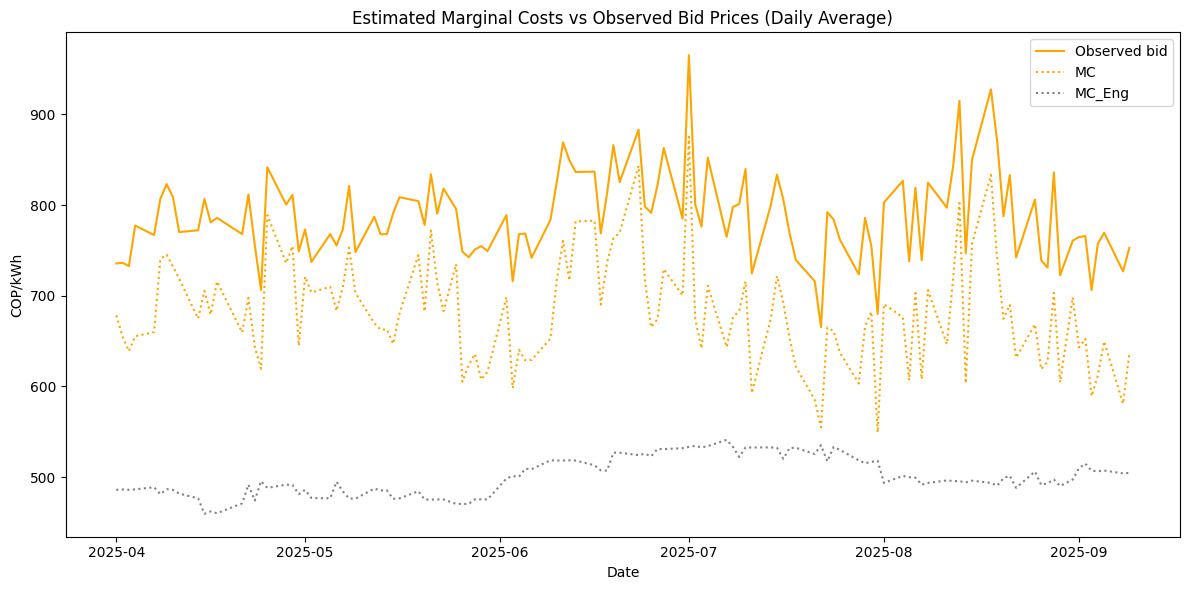

In [478]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ruta de salida
output_path = "../results/graficasCostos"
os.makedirs(output_path, exist_ok=True)

# Asegurar formato de fecha
df_ingenieria['Fecha'] = pd.to_datetime(df_ingenieria['Fecha'])

# Agrupar por día
df_time = df_ingenieria.groupby('Fecha')[["phi", "phi_eng", "precio_d"]].mean()

# Crear gráfica
plt.figure(figsize=(12,6))

plt.plot(df_time.index, df_time['precio_d'], color='orange', linestyle='-', label='Observed bid')
plt.plot(df_time.index, df_time['phi'], color='orange', linestyle=':', label='MC')
plt.plot(df_time.index, df_time['phi_eng'], color='gray', linestyle=':', label='MC_Eng')

plt.title('Estimated Marginal Costs vs Observed Bid Prices (Daily Average)')
plt.xlabel('Date')
plt.ylabel('COP/kWh')
plt.legend()
plt.grid(False)

plt.tight_layout()

# Guardar figura
file_path = os.path.join(output_path, "serie_temporal_costos.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

# Mostrar
plt.show()

In [480]:
df_ingenieria1.columns

Index(['CodigoPlanta', 'phi', 'precio_d', 'Fecha', 'id_planta',
       'Combustible por Defecto', 'Nombre Recurso', 'Agente Representante',
       'ACPM', 'CARBON', 'GAS', 'GAS NI', 'COMBUSTOLEO', 'VOM', 'CERE',
       'FAZNI', 'trm'],
      dtype='object')

In [481]:
df_ingenieria1.to_csv('../datos/procesado/finalingenieria.csv')